## Лабораторна робота 4. **REGRESSION** 📈

# Опис вибірки "Motorbike Ambulance Calls"


Аварії за участю мотоциклів та відповідні виклики швидкої допомоги сильно залежать від екологічних та сезонних умов, таких як погодні умови, опади, день тижня, сезон, година дня тощо. Дані збирались протягом двох років щогодини та потім співвідносилися з відповідною погодою та сезонністю.

Основні характеристики вибірки `motorbike_ambulance_calls.csv`:

              - index: record index
              - date : date
              - season : season (1:springer, 2:summer, 3:fall, 4:winter)
              - yr : year (0: 2011, 1:2012)
              - mnth : month ( 1 to 12)
              - hr : hour (0 to 23)
              - holiday : whether day is holiday or not
              - weekday : day of the week
              - workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
              -  weathersit :
                      - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
                      - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
                      - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
                      - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
              - temp : Normalized temperature in Celsius. The values are divided to 41 (max)
              - atemp: Normalized feeling temperature in Celsius. The values are divided to 50 (max)
              - hum: Normalized humidity. The values are divided to 100 (max)
              - windspeed: Normalized wind speed. The values are divided to 67 (max)
              - cnt: count of total ambulance calls

## Імпорт необхідних бібліотек та завантаження даних

**Завдання 1** підготовка даних до опрацювання

1. завантажте вибірку `motorbike_ambulance_calls.csv`;   
2. підключіть необхідні бібліотеки;  
3. вивести основну статистичну інформацію по числовим змінним;  
4. окремо вивести максимальні та мінімальні значення по всім змінним;  
5. вивести розмірність датасету;

In [1]:
import pandas as pd
import numpy as np
import scipy as sc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
def get_data(data_path: str):
  data = pd.read_csv(data_path)
  return data
data = get_data(data_path='/content/motorbike_ambulance_calls.csv')

In [3]:
print(data.describe)
max = np.max(data, axis=0)
min = np.min(data, axis=0)
print(max)
print(min)
shape = data.shape
print(shape)

<bound method NDFrame.describe of        index      date  season  yr  mnth  hr  holiday  weekday  workingday  \
0          1    1/1/11  spring   0     1   0        0        6           0   
1          2    1/1/11  spring   0     1   1        0        6           0   
2          3    1/1/11  spring   0     1   2        0        6           0   
3          4    1/1/11  spring   0     1   3        0        6           0   
4          5    1/1/11  spring   0     1   4        0        6           0   
...      ...       ...     ...  ..   ...  ..      ...      ...         ...   
17374  17375  12/31/12  spring   1    12  19        0        1           1   
17375  17376  12/31/12  spring   1    12  20        0        1           1   
17376  17377  12/31/12  spring   1    12  21        0        1           1   
17377  17378  12/31/12  spring   1    12  22        0        1           1   
17378  17379  12/31/12  spring   1    12  23        0        1           1   

       weathersit  temp   ate

**Завдання 2** перевірити типи даних та перевірте кількість даних по кожній змінній.

In [4]:
print(data.dtypes)
print(data.count())

index           int64
date           object
season         object
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
cnt             int64
dtype: object
index         17379
date          17379
season        17379
yr            17379
mnth          17379
hr            17379
holiday       17379
weekday       17379
workingday    17379
weathersit    17379
temp          17379
atemp         17379
hum           17379
windspeed     17379
cnt           17379
dtype: int64


**Завдання 3** пепевірте всі змінні на наявність пропусків.

In [5]:
null_data = data.isnull().sum()
print(null_data)

index         0
date          0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64


**Висновки з 1-3 завдання (детальні)**

**текст жирним шрифтом**

1. Датасет складається з 17379 рядків і 15 стовпців. Датасет має такі значення по зміним

index:          17379(max) 1(min)

date:          9/9/12(max) 1/1/11(min)

season:        winter(max) autumn(min)

yr:                 1(max) 0(min)

mnth:              12(max) 1(min)

hr:                23(max) 0(min)

holiday:            1(max) 0(min)

weekday:            6(max) 0(min)

workingday:         1(max) 0(min)

weathersit:         4(max) 1(min)

temp:             1.0(max) 0.02(min)

atemp:            1.0(max) 0.0(min)

hum:              1.0(max) 0.0(min)

windspeed:     0.8507(max) 0.0(min)

cnt:              977(max) 1(min)
2.   В кожної змінної однакова кількість даних. В змінних такі типи даних:

index:           int64

date:           object

season:         object

yr:              int64

mnth:            int64

hr:              int64

holiday:         int64

weekday:         int64

workingday:      int64

weathersit:      int64

temp:          float64

atemp:         float64

hum:           float64

windspeed:     float64

cnt:             int64
3. Всі змінні мають всі значення



**Завдання 4** перетворіть змінну `date` в **date type**. Визначте часові межі датасету.

In [6]:
def tranform_date(df: pd.DataFrame, date_col_name: str):
  df[date_col_name] = pd.to_datetime(df[date_col_name], format="%m/%d/%y")
  return df

data = tranform_date(data, 'date')

In [7]:
def get_time_limits(df: pd.DataFrame, date_col_name: str):
  first_day = df[date_col_name].min()
  last_day = df[date_col_name].max()
  print(f"First day of dataset - {first_day}.\n Last day of dataset - {last_day}")
get_time_limits(data, 'date')

First day of dataset - 2011-01-01 00:00:00.
 Last day of dataset - 2012-12-31 00:00:00


Дані в датасеті записані з 2011-01-01 00:00:00 до 2012-12-31 00:00:00

#Аналіз категоріальних змінних

**Завдання 5** виділити категоріальні змінні в окремий датасет







In [8]:
data_categorical = data[['date', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday']]

**Завдання 6** перетворіть змінну `season` в числову шкалу.

In [9]:
def encode_season(df: pd.DataFrame, season_col_name: str):
  df[season_col_name] = pd.factorize(df[season_col_name])[0]
  return df

data = encode_season(data, 'season')

**Завдання 7** побудувати графіки `countplot` по всім категоріальним змінним

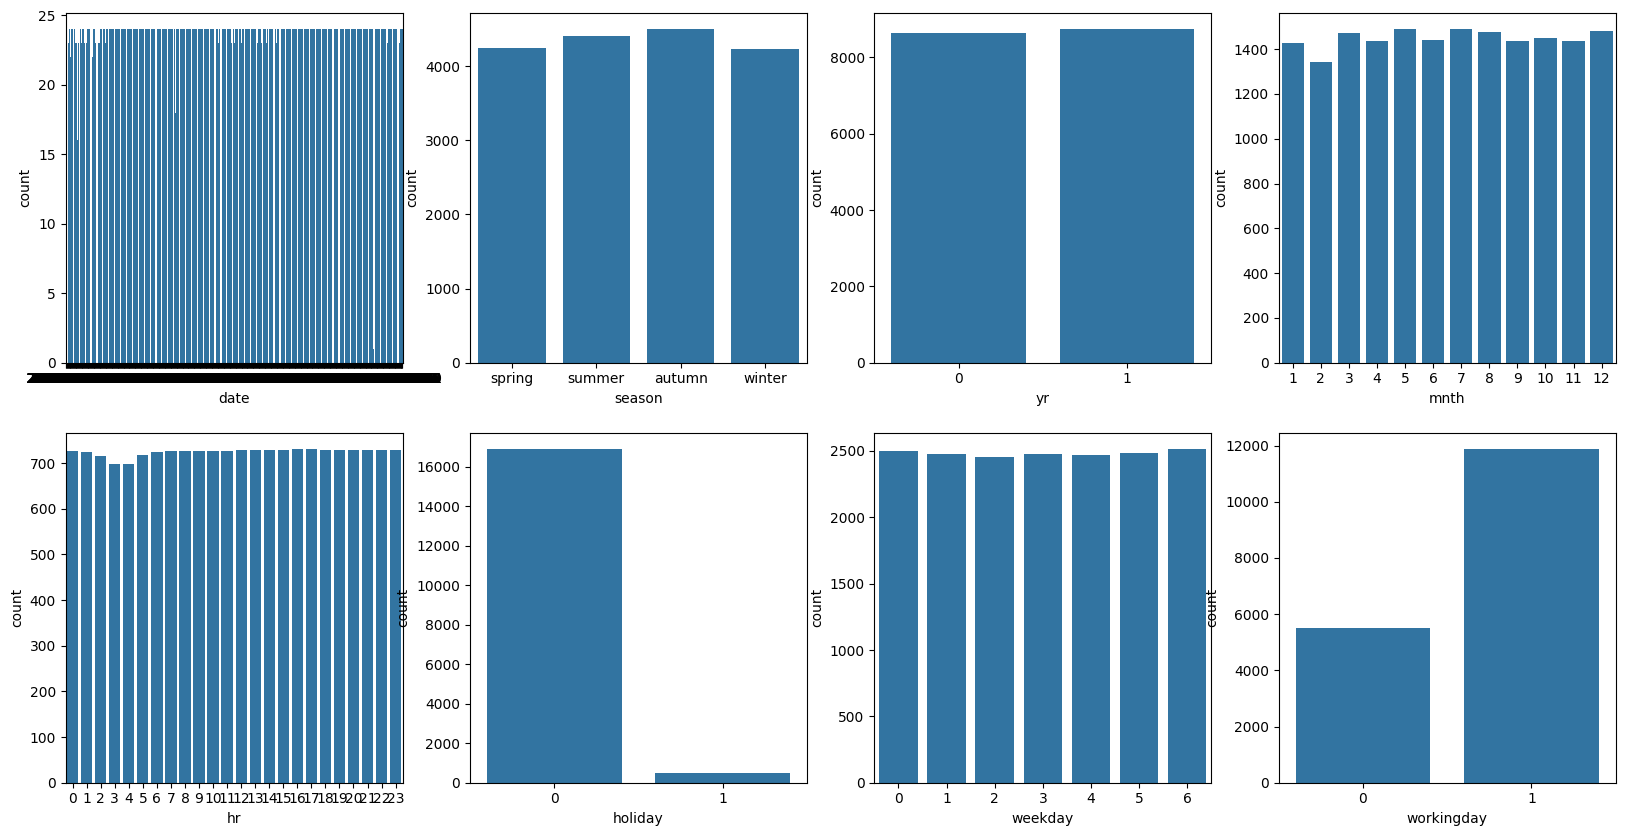

In [10]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10))
for variable, subplot in zip(data_categorical, ax.flatten()):
  sns.countplot(x=variable, data=data_categorical, ax=subplot)
plt.show()

**Висновки з 5-7 завдання (детальні)**

1. Є 8 категоріальних змінних: date, season, yr, mnth, hr, holiday, weekday, workingday.   
2. Змінна season містить чотири можливих категорії і тому вона може бути перетворена в числову шкалу.
3. У всі дні в які були зроблені дзвінки їх надїодила майже одна і така ж кількість(24), найбільше дзвінків(з малим відривом, але все ж існуючим) було восени, за другий рік було трошки більше дзвінків, найменше дзвінків в лютому, найрідше дзвінки робили між третьою і четвертою годинами ранку, більшість днів коли ставались виклики не були святами, виклики були впродовж всього тижня, однаково як в вихідні так і в будні дні.



#Аналіз числових змінних

**Завдання 8** виділити числові змінні в окремий датасет

In [11]:
data_numerical = data.select_dtypes(include=['number'])

**Завдання 9** побудуйте гістограми розподілу по всім числовим змінним

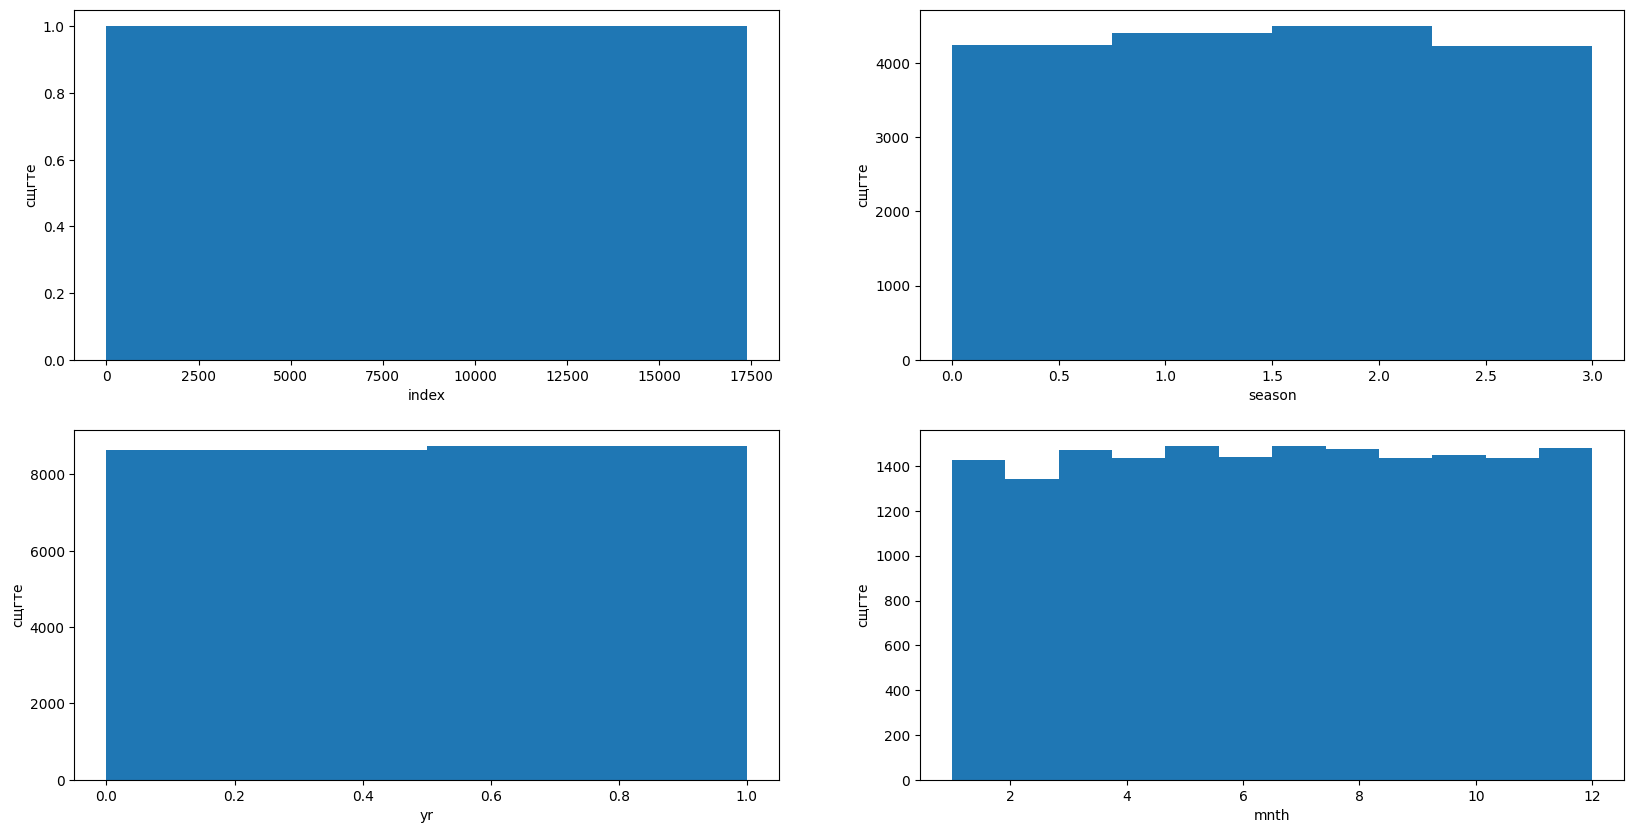

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(20, 10))
for variable, subplot in zip(data_numerical.columns, ax.flatten()):
  bins = data_numerical[variable].nunique()
  subplot.hist(data_numerical[variable], bins=bins)
  subplot.set_xlabel(variable)
  subplot.set_ylabel('сщгте')

**Завдання 10** побудуйте гістограму розподілу цільової змінної та розрахуйте коефіціент нахилу

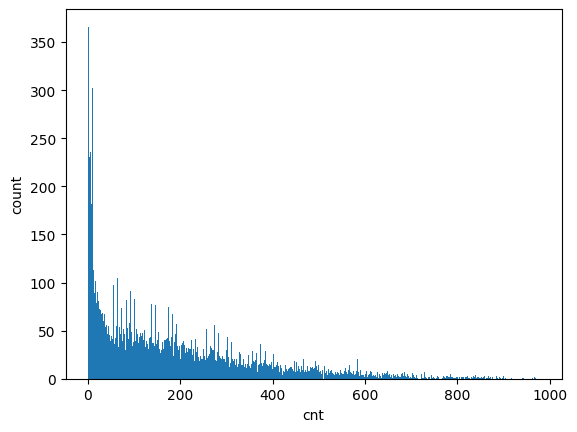

1.2773013463494975


In [13]:
bins = data['cnt'].nunique()
plt.hist(data['cnt'], bins=bins)
plt.xlabel('cnt')
plt.ylabel('count')
plt.show()
skew = sc.stats.skew(data['cnt'])
print(skew)

**Висновки з 8-10 завдання (детальні)**

1.  Категоріальні змінні можуть бути і числовими змінними також, більшість наших змінних є числовими(10).
2. Більшість наших змінних є числовими(10), але ми виводимо перші чотири чомусь(я не стану змінювати, або стерати код, що був написаний до завдання за раніше), я пояснював частину цих графіків в попередньому завданні, тому розкажу про графік index, для створення правильного графіка index потрібно було додати цей рядок, бо графік показувався неправильно, графік без цього рядка показує те, що кількість кожного значення змінної index дорівнює її кількості, що є неправильним:

bins = data_numerical[variable].nunique()

  Також з першого графіка миможемо зробити висновок, що всі значення там повторюються тільки 1 раз і їх кількість 1739.
3. Графік cnt це центральний графік, на мою думку, цей графік показує учасників дтп, з цього графіка ми можемо зробити висновок, що найбільше дзвінків про дтп з малою кількістю учасників(на щастя).



#Аналіз взаємозв'язків між числовими і категоріальними змінними

**Завдання 11** побудуйте графіки співвідношення `scatterplot` між всіма числовими змінними і цільовою змінною `cnt`

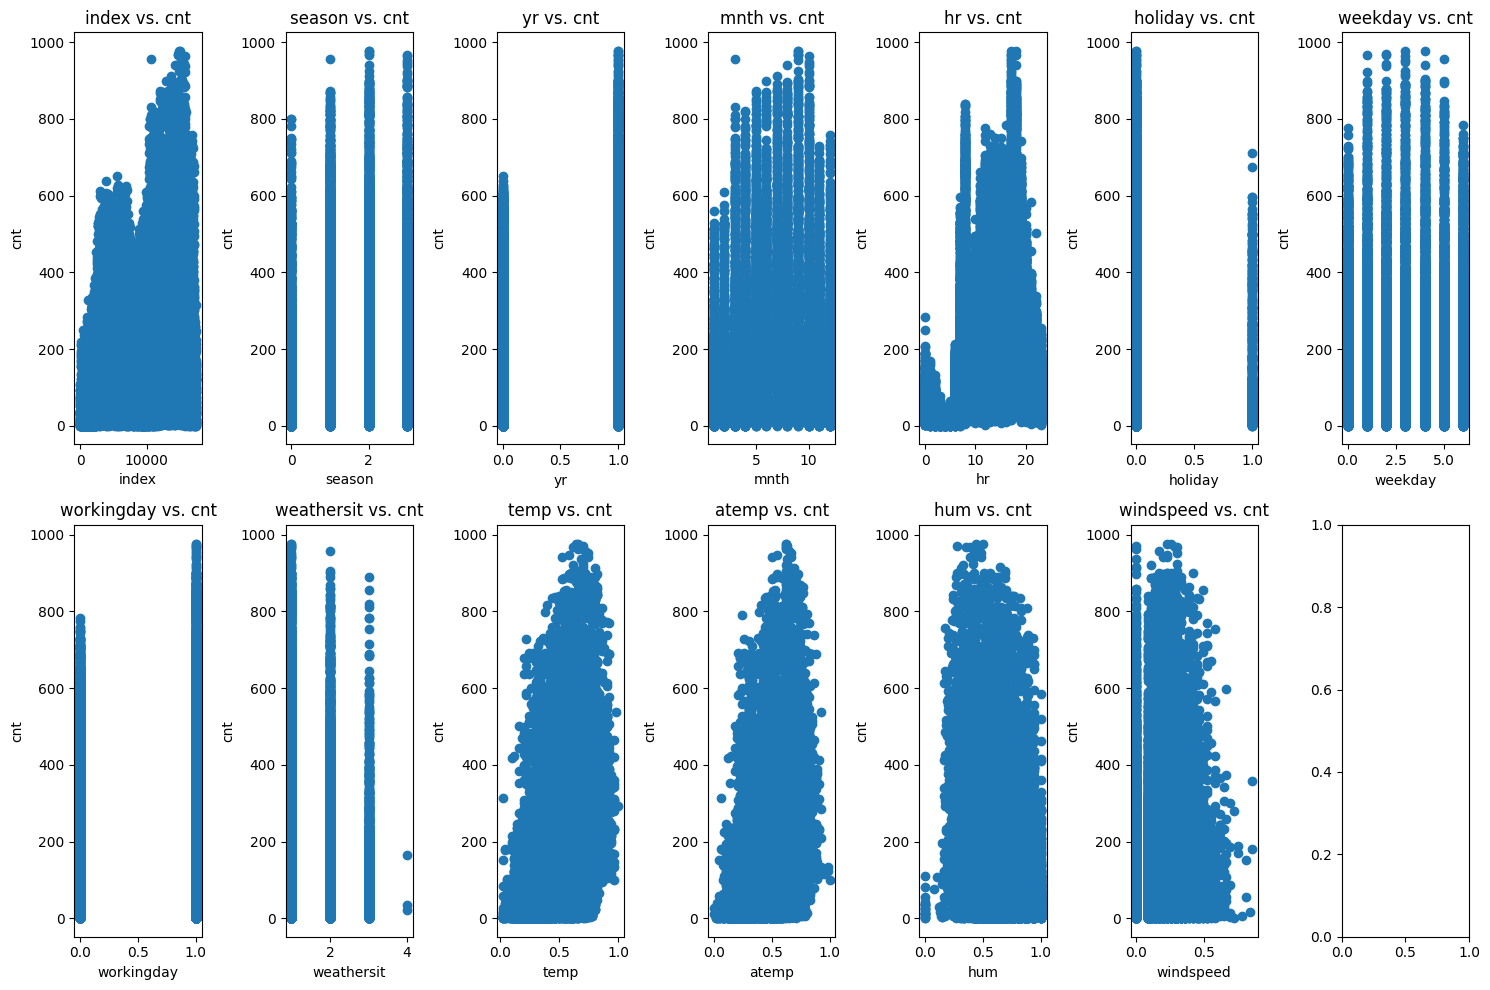

In [19]:
fig, ax = plt.subplots(2,7, figsize=(15, 10))
for var, subplot in zip(data_numerical.drop('cnt', axis =1), ax.flatten()):
  subplot.scatter(data_numerical[var], data_numerical['cnt'])
  subplot.set_xlabel(var)
  subplot.set_ylabel('cnt')
  subplot.set_title(f"{var} vs. cnt")

plt.tight_layout()
plt.show()

**Завдання 12** побудуйте графіки співвідношення `boxplot`[boxplot](https://matplotlib.org/stable/gallery/statistics/boxplot_demo.html) між категоріальними змінними і цільовою змінною `cnt`.

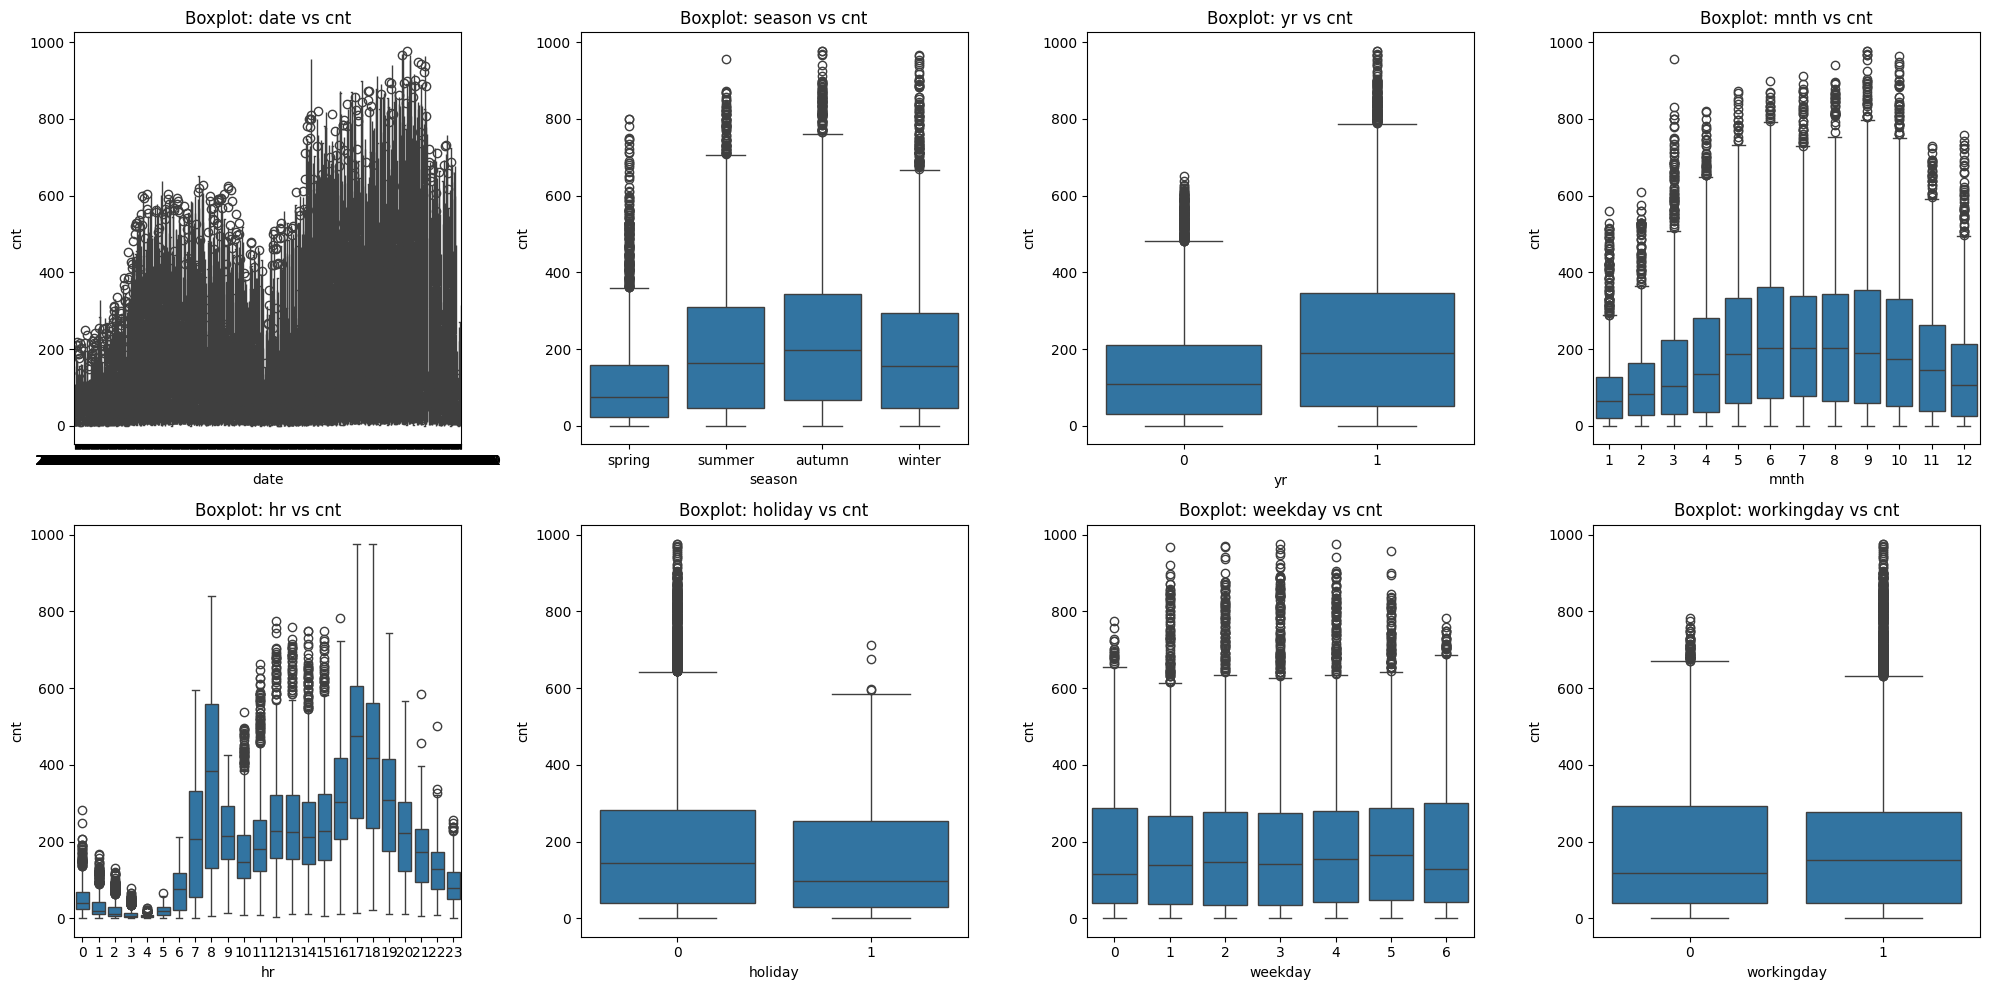

In [16]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10))
for var, subplot in zip(data_categorical, ax.flatten()):
  sns.boxplot(x=data_categorical[var], y=data['cnt'], ax=subplot)
  subplot.set_title(f"Boxplot: {var} vs cnt")
  subplot.set_xlabel(var)
  subplot.set_ylabel("cnt")

plt.tight_layout()
plt.show()

**Висновки з 11-12 завдання (детальні)**

Спершу хочу уточнити, що всетаки збільшив кількість табличок.
1. temp vs cnt: зі збільшенням температури зростає кількість викликів, я дозволю собі припустити, що через збільшення температури зростає активність людей і тому можливо частіше стаються аварії і надходить більше дзвінків.

atemp vs cnt: ті ж самі висновки, що з попередньої таблички, але з більшим розкидом, отже інші чинники також мають не малий вплив.

hum vs cnt: більша вологість = люди обережніше їздять, через це менше аварій і викликів.

windspeed vs cnt: чомусь данні цієї таблички найбільше розкидані, можливо вітер не грає великої ролі.
2. season: графік boxplot вказує, що різні сезони можуть показувати відмінності у центральних показниках та розкиді викликів, це може наштовхувати нас на сезонний вплив.

yr: розподіл за роками показує зсув у медіанах та варіації.

mnth: порівнюючи місяці, видно, що деякі з них мають значно вищі або нижчі медіані cnt. Це вказує знову на наявність сезонних коливань.

hr: наявність вигнутих розподілів у певні години може вказувати на специфічні часові патерни використання послуг.

holiday: порівняння викликів у святкові та не святкові дні показує, що розподіл cnt може значно відрізнятися. Наприклад, у святкові дні медіана може бути нижчою або мати більшу варіативність.

weekday: розподіл по днях тижня часто виявляє відмінності між робочими днями та вихідними. Це допомагає зрозуміти, як змінюється поведінка людей залежно від того, який саме день тижня.

workingday: графік boxplot для робочих і неробочих днів показує, що активність суттєво змінюється.

weathersit: різні категорії погодних умов демонструють відмінні розподіли cnt. Наприклад, нормальні погодні умови можуть бути пов’язані з більшою кількістю викликів, тоді як екстремально несприятлива погода може змінювати цей показник через зміну поведінки людей.


**Завдання 13** Побудувати матрицю кореляції:  

1.   Вирахувати кореляційні коефіціенти для набору данних за методом Пірсона
2.   Відобразити отриману матрицю коефіціентів у вигляді теплокарти  
3.   Вирахувати кореляційні коефіціенти для набору данних за методом Спірмана
4.   Відобразити отриману матрицю коефіціентів у вигляді теплокарти

5. Описати отримані результати, спираючись на значення коефіціентів кореляції та пояснити в чому відмінність обраних методів.

In [ ]:
#your code

In [ ]:
#your conclusions

**Завдання 14**
1. побудувати модель лінійної регресії:
2. видалити змінні, які НЕ є релевантними;

3. поділити вибірку на `train`, `test` та `validation` в пропорції `70/30`;  

4. провести навчання моделі лінійної регресії;

1. Для подальшої роботи з моделями для кожної категоріальної змінної ми створимо фіктивні змінні, щоб уникнути неправильного порядку категорій. [get_dummies](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html)

In [ ]:
def get_dummies(df: pd.DataFrame):
  features = pd.concat([df,
                      # example:
                      pd.get_dummies(df['season']),
                      #YOUR CODE
                      ], axis = 1
                     )
  features = features.drop(['season',
                            'mnth',
                            'weekday',
                            'weathersit'
                            ], axis = 1)
  return fetures

In [ ]:
features = get_dummies(data)

2. На основі змінної часу створіть нову змінну, яка відповідатиме за день і ніч.

In [ ]:
features['night_hours'] = #your code
features = features.drop('hr', axis = 1)

**Модель лінійної регрессії  

[train_linear_model](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

Після отримання фіктивних змінних потрібно видалити по одній з кожної категорії, щоб запобігти мультиколінеарності. Також видаляємо ще два атрибути `date` та `atemp` - поясніть чому?

In [ ]:
features_lr = features.drop(['spring', 'mnth_4', 'weekday_0', 'weathersit_1', 'hr_0','atemp', 'date'], axis = 1)

In [ ]:
def get_train_data(df: pd.DataFrame, target:str, test_size:float):
  X = #your code (all features)
  y = #your code (target variable)
  X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size=test_size, random_state=42, shuffle = True)
  return X_train, X_test, y_train, y_test

In [ ]:
X_train, X_test, y_train, y_test = get_train_data(features_lr, 'cnt', 0.3)

In [ ]:
def train_linear_model(X_train, y_train):
  model = LinearRegression()
  model.fit(X_train, y_train)
  return model

model = train_linear_model(X_train, y_train)

In [ ]:
# predict
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
# scores
print('MSE train: {:.3f}, test: {:.3f}'.format(
        mean_squared_error(y_train, y_train_pred),
        mean_squared_error(y_test, y_test_pred)))
print('R^2 train: {:.3f}, test: {:.3f}'.format(
        r2_score(y_train, y_train_pred),
        r2_score(y_test, y_test_pred)))

Оскільки в нашій моделі є багато незалежних змінних, ми не можемо відобразити їх залежність у двовимірному просторі, але ми можемо побудувати графік взаємозв'язку між залишками моделі та передбачуваними значеннями, що також допоможе нам оцінити якість моделі.

In [ ]:
plt.scatter(y_train_pred,  y_train_pred - y_train,
            c='#5f93ad', marker='o', label='Training data')
plt.scatter(y_test_pred,  y_test_pred - y_test,
            c='#98c3d9', marker='s', label='Test data')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.legend(loc='upper left')
plt.hlines(y=0, xmin=-220, xmax=1000, lw=2, color='#000000')
plt.tight_layout()

**Висновки з завдання (детальні)**



1.   
2.   
3. ...

